# Ablation Study — Multi-Relational WIRE Graph Transformer

**Purpose:** Test whether each fundamental graph independently contributes to WIRE performance.

**Configs compared (10 seeds each):**
1. **LSTM Baseline** — no graph structure
2. **Sector-only** — GICS sector graph (5 spectral dims)
3. **TNIC-only** — Hoberg-Phillips competitor graph (6 spectral dims)
4. **Ownership-only** — 13F co-holding overlap graph (5 spectral dims)
5. **Full (v3.0)** — All three concatenated (16 spectral dims)

**Training config:** Identical to v3.0 (ic_loss, rank-normalized targets, smoothed early stopping, dropout 0.5, RoPE omega init, no Q/K detach)

**Data pipeline:** Identical to v3.0 (N=300, 25 features, LOOKBACK=20, HORIZON=5)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
OUT_DIR = "/content/drive/MyDrive/2026 Spring/STAT 3106/3106_Projects/Projects/output/v_ablation"
os.makedirs(OUT_DIR, exist_ok=True)
print(f"Output -> {OUT_DIR}")

Mounted at /content/drive
Output -> /content/drive/MyDrive/2026 Spring/STAT 3106/3106_Projects/Projects/output/v_ablation


In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from scipy.sparse.csgraph import laplacian
from scipy.linalg import eigh
from scipy.stats import spearmanr, ttest_rel, rankdata
from scipy.sparse import csr_matrix
import json, time, warnings
warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}, PyTorch: {torch.__version__}")

Device: cuda, PyTorch: 2.10.0+cu128


## 1. Data Pipeline (identical to v3.0)

In [ ]:
DATA = "/content/drive/MyDrive/2026 Spring/STAT 3106/3106_Projects/Projects/Data"
crsp = pd.read_csv(f"{DATA}/qf0egyr4ffi0pszj.csv", parse_dates=["DlyCalDt"])
crsp = crsp.sort_values(["PERMNO", "DlyCalDt"]).reset_index(drop=True)
compustat = pd.read_csv(f"{DATA}/gg3axrtvut5hi5hh.csv", parse_dates=["datadate"])
compustat = compustat.rename(columns={"LPERMNO": "PERMNO"})
print(f"CRSP: {crsp.shape[0]:,} rows, {crsp['PERMNO'].nunique()} stocks")
print(f"Compustat: {compustat.shape[0]:,} rows, {compustat['PERMNO'].nunique()} stocks")

N_TARGET = 300
date_range = crsp["DlyCalDt"].nunique()
stock_counts = crsp.groupby("PERMNO")["DlyCalDt"].count()
valid_permnos = stock_counts[stock_counts >= date_range * 0.8].index
gsector_map = compustat.drop_duplicates("PERMNO", keep="last").set_index("PERMNO")["gsector"]
valid_permnos = valid_permnos[valid_permnos.isin(gsector_map.index)]
avg_vol = crsp[crsp["PERMNO"].isin(valid_permnos)].groupby("PERMNO")["DlyVol"].mean()
top_permnos = sorted(avg_vol.nlargest(N_TARGET).index.tolist())
crsp_sub = crsp[crsp["PERMNO"].isin(top_permnos)].copy()
permno_to_idx = {p: i for i, p in enumerate(top_permnos)}
N_STOCKS = len(top_permnos)
sectors = np.array([gsector_map.get(p, -1) for p in top_permnos])
print(f"Selected {N_STOCKS} stocks, {len(crsp_sub):,} daily records")

CRSP: 1,768,234 rows, 756 stocks
Compustat: 27,236 rows, 745 stocks
Selected 300 stocks, 823,065 daily records


In [ ]:
print("Computing technical indicators per stock...")
t0 = time.time()

def add_technicals(df):
    results = []
    total = df["PERMNO"].nunique()
    for i, (permno, g) in enumerate(df.groupby("PERMNO")):
        if (i + 1) % 100 == 0:
            print(f"  {i+1}/{total} stocks...")
        g = g.sort_values("DlyCalDt").copy()
        c, h, l, v, r = g["DlyPrc"], g["DlyHigh"], g["DlyLow"], g["DlyVol"], g["DlyRet"]
        cs = c.replace(0, np.nan)
        delta = c.diff()
        avg_gain = delta.clip(lower=0).ewm(span=14, adjust=False).mean()
        avg_loss = (-delta).clip(lower=0).ewm(span=14, adjust=False).mean()
        g["RSI"] = (100 - 100 / (1 + avg_gain / avg_loss.replace(0, np.nan))) / 100
        ema12 = c.ewm(span=12, adjust=False).mean()
        ema26 = c.ewm(span=26, adjust=False).mean()
        macd = ema12 - ema26
        g["MACD_hist"] = (macd - macd.ewm(span=9, adjust=False).mean()) / cs
        sma20 = c.rolling(20, min_periods=10).mean()
        std20 = c.rolling(20, min_periods=10).std()
        g["BB_pctB"] = (c - (sma20 - 2 * std20)) / (4 * std20).replace(0, np.nan)
        tr = pd.concat([h - l, (h - c.shift(1)).abs(), (l - c.shift(1)).abs()], axis=1).max(axis=1)
        g["ATR_norm"] = tr.rolling(14, min_periods=7).mean() / cs
        for w in [5, 20, 60]:
            sma = c.rolling(w, min_periods=max(1, w // 2)).mean()
            g[f"close_sma{w}"] = c / sma.replace(0, np.nan)
        for w in [5, 20]:
            g[f"mom_{w}d"] = c.pct_change(w)
        for w in [5, 20]:
            g[f"rvol_{w}d"] = r.rolling(w, min_periods=max(1, w // 2)).std() * np.sqrt(252)
        g["vol_ratio"] = v / v.rolling(20, min_periods=10).mean().replace(0, np.nan)
        g["log_vol_chg"] = np.log1p(v).diff()
        g["ba_spread"] = (g["DlyAsk"] - g["DlyBid"]) / cs
        g["turnover"] = v / (g["ShrOut"].replace(0, np.nan) * 1000)
        g["excess_ret"] = r - g["sprtrn"]
        results.append(g)
    return pd.concat(results, ignore_index=True)

crsp_sub = add_technicals(crsp_sub)
print(f"Done in {time.time() - t0:.1f}s")

Computing technical indicators per stock...
  100/300 stocks...
  200/300 stocks...
  300/300 stocks...
Done in 4.3s


In [ ]:
TECH_COLS = ["RSI", "MACD_hist", "BB_pctB", "ATR_norm",
             "close_sma5", "close_sma20", "close_sma60",
             "mom_5d", "mom_20d", "rvol_5d", "rvol_20d",
             "vol_ratio", "log_vol_chg", "ba_spread", "turnover", "excess_ret"]
FUND_COLS = ["roe", "leverage", "profit_margin", "log_assets"]
FEATURE_NAMES = (["close", "open_close", "high_close", "low_close", "log_vol", "return"]
                 + TECH_COLS + FUND_COLS)

def build_feature_tensor(df, permnos, p2i):
    dates = sorted(df["DlyCalDt"].unique())
    T, N = len(dates), len(permnos)
    F = 6 + len(TECH_COLS)
    feat = np.full((T, N, F), np.nan, dtype=np.float32)
    d2t = {d: t for t, d in enumerate(dates)}
    df = df.copy()
    df["_t"] = df["DlyCalDt"].map(d2t)
    df["_n"] = df["PERMNO"].map(p2i)
    df = df.dropna(subset=["_t", "_n"])
    t = df["_t"].astype(int).values
    n = df["_n"].astype(int).values
    c = df["DlyPrc"].values.astype(np.float32)
    cs = np.where(c == 0, 1.0, c)
    feat[t, n, 0] = c
    feat[t, n, 1] = df["DlyOpen"].values / cs
    feat[t, n, 2] = df["DlyHigh"].values / cs
    feat[t, n, 3] = df["DlyLow"].values / cs
    feat[t, n, 4] = np.log1p(df["DlyVol"].values)
    feat[t, n, 5] = df["DlyRet"].values
    for i, col in enumerate(TECH_COLS):
        feat[t, n, 6 + i] = df[col].values
    return feat, dates

features, dates = build_feature_tensor(crsp_sub, top_permnos, permno_to_idx)
print(f"Base tensor: {features.shape}")

fund = compustat[["PERMNO", "datadate", "rdq", "atq", "ceqq", "niq"]].copy()
fund["rdq"] = pd.to_datetime(fund["rdq"])
fund["avail_date"] = fund["rdq"].fillna(fund["datadate"] + pd.Timedelta(days=45))
def safe_ratio(num, denom, clip=10):
    return (num / denom.replace(0, np.nan)).clip(-clip, clip)
fund["roe"] = safe_ratio(fund["niq"], fund["ceqq"])
fund["leverage"] = safe_ratio(fund["atq"], fund["ceqq"])
fund["profit_margin"] = safe_ratio(fund["niq"], fund["atq"])
fund["log_assets"] = np.log1p(fund["atq"].clip(lower=0))

T, N, F_base = features.shape
fund_feat = np.full((T, N, len(FUND_COLS)), np.nan, dtype=np.float32)
dates_arr = np.array(dates)
print("Merging fundamentals...")
for permno in top_permnos:
    ni = permno_to_idx[permno]
    sf = fund[fund["PERMNO"] == permno].sort_values("avail_date")
    for _, row in sf.iterrows():
        mask = dates_arr >= row["avail_date"]
        if mask.any():
            fund_feat[mask, ni, :] = [row[c] for c in FUND_COLS]
features = np.concatenate([features, fund_feat], axis=2)

print("Filling NaN...")
for n in range(N):
    df_tmp = pd.DataFrame(features[:, n, :])
    features[:, n, :] = df_tmp.ffill().bfill().values

clip_map = {
    6: (0, 1), 7: (-0.1, 0.1), 8: (-1, 2), 9: (0, 0.5),
    10: (0.5, 2.0), 11: (0.5, 2.0), 12: (0.5, 2.0),
    13: (-0.5, 0.5), 14: (-0.5, 0.5), 15: (0, 2.0), 16: (0, 2.0),
    17: (0, 10.0), 19: (-0.01, 0.1), 20: (0, 0.1), 21: (-0.2, 0.2),
}
for idx, (lo, hi) in clip_map.items():
    features[:, :, idx] = np.clip(features[:, :, idx], lo, hi)
features = np.nan_to_num(features, nan=0.0)
INPUT_DIM = features.shape[2] - 1
print(f"Final tensor: {features.shape}, INPUT_DIM={INPUT_DIM}")

Base tensor: (2766, 300, 22)
Merging fundamentals...
Filling NaN...
Final tensor: (2766, 300, 26), INPUT_DIM=25


## 2. Multi-Relational Graphs & Spectral Coordinates

In [ ]:
CORR_WINDOW = 60

def mp_denoise(corr, T, N):
    eigenvalues, eigenvectors = np.linalg.eigh(corr)
    gamma = N / T
    lambda_plus = (1 + np.sqrt(gamma)) ** 2
    signal_mask = eigenvalues > lambda_plus
    n_signal = signal_mask.sum()
    if 0 < n_signal < N:
        signal_sum = eigenvalues[signal_mask].sum()
        noise_val = max((N - signal_sum) / (N - n_signal), 0.0)
        eigenvalues[~signal_mask] = noise_val
    corr_denoised = (eigenvectors * eigenvalues) @ eigenvectors.T
    d = np.sqrt(np.maximum(np.diag(corr_denoised), 1e-10))
    corr_denoised /= np.outer(d, d)
    np.fill_diagonal(corr_denoised, 1.0)
    return corr_denoised.astype(np.float32), n_signal

def spectral_coords_from_graph(A, n_dims, name=""):
    A = A + 0.001 * (1 - np.eye(A.shape[0], dtype=np.float32))
    L = laplacian(A, normed=True)
    evals, evecs = eigh(L)
    nonzero = np.where(evals > 1e-10)[0]
    n_components = (evals <= 1e-10).sum()
    if len(nonzero) >= n_dims:
        sc = evecs[:, nonzero[:n_dims]].astype(np.float32)
        gap = evals[nonzero[0]]
    else:
        sc = np.zeros((A.shape[0], n_dims), dtype=np.float32)
        if len(nonzero) > 0:
            sc[:, :len(nonzero)] = evecs[:, nonzero].astype(np.float32)
        gap = evals[nonzero[0]] if len(nonzero) > 0 else 0.0
    sc = (sc - sc.mean(axis=0)) / (sc.std(axis=0) + 1e-8)
    n_edges = int((A > 0.002).sum() / 2)  # exclude perturbation-only edges
    print(f"  [{name}] {n_dims}D | edges: {n_edges:,} | components: {n_components} | gap: {gap:.6f}")
    return sc

# ── Graph 1: Sector (GICS) ──
def build_adjacency(labels):
    L = labels.reshape(-1, 1)
    A = ((L == L.T) & (L != -1)).astype(np.float32)
    np.fill_diagonal(A, 0)
    return A

A_sector = build_adjacency(sectors)
sc_sector = spectral_coords_from_graph(A_sector, 5, "Sector (GICS)")

# ── Graph 2: TNIC Competitor ──
print("  Loading TNIC...")
tnic = pd.read_csv(f"{DATA}/tnic3_filtered.csv")
gvkey_to_idx = {}
for _, row in compustat[["GVKEY", "PERMNO"]].drop_duplicates("GVKEY", keep="last").iterrows():
    try:
        gvk = int(row["GVKEY"])
        if row["PERMNO"] in permno_to_idx:
            gvkey_to_idx[gvk] = permno_to_idx[row["PERMNO"]]
    except (ValueError, TypeError):
        pass
tnic_year = tnic["year"].max()
tnic_sub = tnic[(tnic["year"] == tnic_year) & (tnic["gvkey1"] != tnic["gvkey2"])]
A_tnic = np.zeros((N_STOCKS, N_STOCKS), dtype=np.float32)
for _, row in tnic_sub.iterrows():
    i = gvkey_to_idx.get(int(row["gvkey1"]))
    j = gvkey_to_idx.get(int(row["gvkey2"]))
    if i is not None and j is not None:
        A_tnic[i, j] = row["score"]
        A_tnic[j, i] = row["score"]
sc_tnic = spectral_coords_from_graph(A_tnic, 6, f"TNIC (year={tnic_year})")

# ── Graph 3: 13F Ownership ──
print("  Loading 13F ownership...")
own = pd.read_csv(f"{DATA}/ownership_13f.csv")
own["cusip8"] = own["cusip"].astype(str).str[:8]
cusip8_to_idx = {}
cusip_lookup = crsp_sub.drop_duplicates("PERMNO", keep="last")[["PERMNO", "HdrCUSIP"]]
for _, row in cusip_lookup.iterrows():
    if row["PERMNO"] in permno_to_idx:
        c8 = str(row["HdrCUSIP"])[:8]
        if c8 and c8 != 'nan':
            cusip8_to_idx[c8] = permno_to_idx[row["PERMNO"]]
own_our = own[own["cusip8"].isin(cusip8_to_idx)].copy()
own_our["stock_idx"] = own_our["cusip8"].map(cusip8_to_idx)
mgr_cats = pd.Categorical(own_our["mgrno"])
H_sparse = csr_matrix(
    (np.ones(len(own_our)), (own_our["stock_idx"].values, mgr_cats.codes)),
    shape=(N_STOCKS, len(mgr_cats.categories)))
H_binary = (H_sparse > 0).astype(np.float32)
intersection = (H_binary @ H_binary.T).toarray()
holdings_per_stock = np.array(H_binary.sum(axis=1)).flatten()
union = holdings_per_stock[:, None] + holdings_per_stock[None, :] - intersection
jaccard = np.where(union > 0, intersection / union, 0).astype(np.float32)
np.fill_diagonal(jaccard, 0)
upper_tri = jaccard[np.triu_indices(N_STOCKS, 1)]
nonzero_sim = upper_tri[upper_tri > 0]
threshold = np.quantile(nonzero_sim, 0.90) if len(nonzero_sim) > 0 else 0
A_ownership = (jaccard > threshold).astype(np.float32) if len(nonzero_sim) > 0 else np.zeros((N_STOCKS, N_STOCKS), dtype=np.float32)
sc_ownership = spectral_coords_from_graph(A_ownership, 5, "13F Ownership")

# ── Full super-coordinate (16 dims) ──
sc_full = np.concatenate([sc_sector, sc_tnic, sc_ownership], axis=1)
print(f"\nSpectral coordinates ready:")
print(f"  Sector:    {sc_sector.shape}")
print(f"  TNIC:      {sc_tnic.shape}")
print(f"  Ownership: {sc_ownership.shape}")
print(f"  Full:      {sc_full.shape}")

  [Sector (GICS)] 5D | edges: 4,917 | components: 1 | gap: 0.006074
  Loading TNIC...
  [TNIC (year=2023)] 6D | edges: 838 | components: 1 | gap: 0.191449
  Loading 13F ownership...
  [13F Ownership] 5D | edges: 4,337 | components: 1 | gap: 0.062983

Spectral coordinates ready:
  Sector:    (300, 5)
  TNIC:      (300, 6)
  Ownership: (300, 5)
  Full:      (300, 16)


## 3. Dataset

In [ ]:
LOOKBACK = 20
HORIZON = 5
CORR_REUSE = 5

returns_all = features[:, :, 5]
T_total = returns_all.shape[0]

valid_times = []
for t in range(LOOKBACK, T_total - HORIZON):
    c_now = features[t, :, 0]
    c_fut = features[t + HORIZON, :, 0]
    valid = ~((c_now == 0) | (c_fut == 0))
    if valid.sum() >= N_STOCKS * 0.5:
        valid_times.append(t)

n_total = len(valid_times)
n_train = int(0.7 * n_total)
n_val = int(0.15 * n_total)

print("Precomputing denoised correlation matrices...")
t0_cache = time.time()
unique_anchors = sorted(set(t // CORR_REUSE * CORR_REUSE for t in valid_times))
corr_cache = {}
for i, anchor in enumerate(unique_anchors):
    if (i + 1) % 200 == 0:
        print(f"  {i+1}/{len(unique_anchors)} anchors...")
    t_start = max(0, anchor - CORR_WINDOW)
    returns = features[t_start:anchor, :, 5]
    T_window = returns.shape[0]
    if T_window >= 20:
        corr = np.corrcoef(returns.T).astype(np.float32)
        corr = np.nan_to_num(corr, nan=0.0)
        corr, _ = mp_denoise(corr, T_window, N_STOCKS)
    else:
        corr = np.eye(N_STOCKS, dtype=np.float32)
    corr_cache[anchor] = corr
print(f"Cached {len(corr_cache)} matrices in {time.time() - t0_cache:.1f}s")

class StockDataset(Dataset):
    def __init__(self, features, times, corr_cache, corr_reuse=CORR_REUSE):
        self.features = features
        self.times = times
        self.corr_cache = corr_cache
        self.corr_reuse = corr_reuse
        self.N = features.shape[1]
    def __len__(self):
        return len(self.times)
    def __getitem__(self, idx):
        t = self.times[idx]
        x = self.features[t - LOOKBACK:t, :, 1:]
        x = np.nan_to_num(x, nan=0.0)
        c_now = self.features[t, :, 0]
        c_fut = self.features[t + HORIZON, :, 0]
        y_raw = np.where(c_now != 0, c_fut / c_now - 1, 0).astype(np.float32)
        ranks = rankdata(y_raw).astype(np.float32)
        y = (2.0 * (ranks - 1.0) / (self.N - 1.0) - 1.0).astype(np.float32)
        anchor = t // self.corr_reuse * self.corr_reuse
        corr = self.corr_cache[anchor]
        return (torch.from_numpy(x.transpose(1, 0, 2).copy()),
                torch.from_numpy(y.copy()),
                torch.from_numpy(corr))

train_ds = StockDataset(features, valid_times[:n_train], corr_cache)
val_ds   = StockDataset(features, valid_times[n_train:n_train + n_val], corr_cache)
test_ds  = StockDataset(features, valid_times[n_train + n_val:], corr_cache)
print(f"Samples: train={len(train_ds)}, val={len(val_ds)}, test={len(test_ds)}")

Precomputing denoised correlation matrices...
  200/549 anchors...
  400/549 anchors...
Cached 549 matrices in 8.1s
Samples: train=1918, val=411, test=412


## 4. Models

In [ ]:
class BaselineLSTM(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, hidden_dim=64, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=2,
                            batch_first=True, dropout=dropout)
        self.head = nn.Sequential(nn.Linear(hidden_dim, 32), nn.ReLU(),
                                  nn.Dropout(dropout), nn.Linear(32, 1))
    def forward(self, x):
        B, N, T, F = x.shape
        _, (h, _) = self.lstm(x.reshape(B * N, T, F))
        return self.head(h[-1]).squeeze(-1).reshape(B, N)


class WIRE(nn.Module):
    def __init__(self, d_model, m_spectral):
        super().__init__()
        omega = torch.zeros(d_model // 2, m_spectral)
        freqs = 1.0 / (10000.0 ** (2.0 * torch.arange(d_model // 2).float() / d_model))
        omega[:, 0] = freqs
        omega[:, 1:] = torch.randn(d_model // 2, m_spectral - 1) * 0.01
        self.omega = nn.Parameter(omega)
    def forward(self, z, sc):
        B, N, H, d = z.shape
        nb = d // 2
        theta = sc @ self.omega.T
        z = z.reshape(B, N, H, nb, 2)
        cos_t = torch.cos(theta)[None, :, None, :, None]
        sin_t = torch.sin(theta)[None, :, None, :, None]
        z0, z1 = z[..., 0:1], z[..., 1:2]
        return torch.cat([z0 * cos_t - z1 * sin_t,
                          z0 * sin_t + z1 * cos_t], dim=-1).reshape(B, N, H, d)


class WIREAttentionLayer(nn.Module):
    def __init__(self, d_model=64, n_heads=4, m_spectral=16, dropout=0.5):
        super().__init__()
        self.d_model, self.n_heads, self.d_k = d_model, n_heads, d_model // n_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.wire = WIRE(self.d_k, m_spectral)
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(d_model)
        self.edge_bias = nn.Parameter(torch.full((n_heads,), 0.1))

    def forward(self, x, sc, corr=None):
        B, N, _ = x.shape
        H, dk = self.n_heads, self.d_k
        Q = self.wire(self.W_q(x).reshape(B, N, H, dk), sc)
        K = self.wire(self.W_k(x).reshape(B, N, H, dk), sc)
        V = self.W_v(x).reshape(B, N, H, dk)
        Q, K, V = [t.permute(0, 2, 1, 3) for t in (Q, K, V)]
        attn_scores = Q @ K.transpose(-2, -1) / dk ** 0.5
        if corr is not None:
            attn_scores = attn_scores + self.edge_bias[None, :, None, None] * corr[:, None, :, :]
        attn = self.dropout(F.softmax(attn_scores, dim=-1))
        out = self.W_o((attn @ V).permute(0, 2, 1, 3).reshape(B, N, self.d_model))
        return self.norm(x + out), attn


class GraphTransformerWIRE(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, hidden_dim=64, n_heads=4,
                 n_layers=2, m_spectral=16, dropout=0.5):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=2,
                            batch_first=True, dropout=0.2)
        self.attn_layers = nn.ModuleList([
            WIREAttentionLayer(hidden_dim, n_heads, m_spectral, dropout)
            for _ in range(n_layers)])
        self.ffns = nn.ModuleList([
            nn.Sequential(nn.Linear(hidden_dim, hidden_dim * 2), nn.GELU(),
                          nn.Dropout(dropout), nn.Linear(hidden_dim * 2, hidden_dim),
                          nn.LayerNorm(hidden_dim))
            for _ in range(n_layers)])
        self.head_lstm = nn.Sequential(nn.Linear(hidden_dim, 32), nn.ReLU(),
                                       nn.Dropout(dropout), nn.Linear(32, 1))
        self.head_wire = nn.Sequential(nn.Linear(hidden_dim, 32), nn.ReLU(),
                                       nn.Dropout(dropout), nn.Linear(32, 1))
        self.mix = nn.Parameter(torch.tensor(0.0))

    def forward(self, x, sc, corr=None):
        B, N, T, F = x.shape
        _, (h, _) = self.lstm(x.reshape(B * N, T, F))
        embed = h[-1].reshape(B, N, self.hidden_dim)
        pred_lstm = self.head_lstm(embed).squeeze(-1)
        z = embed
        for al, ff in zip(self.attn_layers, self.ffns):
            z, _ = al(z, sc, corr)
            z = ff(z) + z
        pred_wire = self.head_wire(z).squeeze(-1)
        alpha = torch.sigmoid(self.mix)
        return alpha * pred_lstm + (1 - alpha) * pred_wire


print(f"BaselineLSTM:         {sum(p.numel() for p in BaselineLSTM().parameters()):,} params")
print(f"GraphTransformerWIRE: {sum(p.numel() for p in GraphTransformerWIRE(m_spectral=16).parameters()):,} params")

BaselineLSTM:         58,689 params
GraphTransformerWIRE: 128,011 params


## 5. Training Utilities

In [ ]:
def rank_ic(pred, actual):
    p = pred.detach().cpu().numpy().flatten()
    a = actual.detach().cpu().numpy().flatten()
    m = ~(np.isnan(p) | np.isnan(a))
    if m.sum() < 10: return 0.0
    c, _ = spearmanr(p[m], a[m])
    return c if not np.isnan(c) else 0.0

def ic_loss(pred, target):
    p = pred - pred.mean(dim=-1, keepdim=True)
    t = target - target.mean(dim=-1, keepdim=True)
    p_norm = p.norm(dim=-1, keepdim=False) + 1e-8
    t_norm = t.norm(dim=-1, keepdim=False) + 1e-8
    cos = (p * t).sum(dim=-1) / (p_norm * t_norm)
    return -cos.mean()

def train_epoch(model, loader, opt, sc=None, mt="lstm"):
    model.train()
    tl, ti, nb = 0, 0, 0
    for batch in loader:
        x, y, corr = batch[0].to(device), batch[1].to(device), batch[2].to(device)
        opt.zero_grad()
        pred = model(x) if mt == "lstm" else model(x, sc, corr)
        loss = ic_loss(pred, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        tl += loss.item(); ti += rank_ic(pred, y); nb += 1
    return tl / nb, ti / nb

@torch.no_grad()
def evaluate(model, loader, sc=None, mt="lstm"):
    model.eval()
    tl, ti, nb = 0, 0, 0
    for batch in loader:
        x, y, corr = batch[0].to(device), batch[1].to(device), batch[2].to(device)
        pred = model(x) if mt == "lstm" else model(x, sc, corr)
        tl += ic_loss(pred, y).item(); ti += rank_ic(pred, y); nb += 1
    return tl / nb, ti / nb

def train_model(model, opt, ltr, lva, sc=None, mt="lstm", epochs=150, patience=30, sched_patience=10):
    best_ic, best_st, wait = -np.inf, None, 0
    ic_history = []
    hist = {"train_loss": [], "val_loss": [], "train_ic": [], "val_ic": []}
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt, mode="min", factor=0.5, patience=sched_patience, min_lr=1e-6)
    blrs = [pg["lr"] for pg in opt.param_groups]
    for ep in range(epochs):
        if ep < 5:
            for pg, bl in zip(opt.param_groups, blrs):
                pg["lr"] = bl * (ep + 1) / 5
        tl, ti = train_epoch(model, ltr, opt, sc, mt)
        vl, vi = evaluate(model, lva, sc, mt)
        if ep >= 5: sched.step(vi)
        hist["train_loss"].append(tl); hist["val_loss"].append(vl)
        hist["train_ic"].append(ti); hist["val_ic"].append(vi)
        ic_history.append(vi)
        avg_ic = np.mean(ic_history[-5:]) if len(ic_history) >= 5 else np.mean(ic_history)
        if avg_ic > best_ic:
            best_ic = avg_ic
            best_st = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
        if (ep + 1) % 10 == 0:
            print(f"    Ep {ep+1:3d} | TrIC:{ti:+.4f} VaIC:{vi:+.4f} best_avg:{best_ic:+.4f}")
        if wait >= patience:
            print(f"    Early stop ep {ep+1} (best_avg: {best_ic:+.4f})")
            break
    if best_st: model.load_state_dict(best_st)
    return hist

print("Training utilities ready.")

Training utilities ready.


## 6. Ablation: 5 Configs x 10 Seeds

In [ ]:
BATCH_SIZE = 16; LR = 1e-3; N_SEEDS = 10

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

# Ablation configs: (name, spectral_coords, m_spectral)
sc_sector_t = torch.tensor(sc_sector, dtype=torch.float32).to(device)
sc_tnic_t   = torch.tensor(sc_tnic,   dtype=torch.float32).to(device)
sc_own_t    = torch.tensor(sc_ownership, dtype=torch.float32).to(device)
sc_full_t   = torch.tensor(sc_full,   dtype=torch.float32).to(device)

CONFIGS = [
    ("LSTM",       None,        0),
    ("Sector",     sc_sector_t, 5),
    ("TNIC",       sc_tnic_t,   6),
    ("Ownership",  sc_own_t,    5),
    ("Full (v3.0)",sc_full_t,  16),
]

all_results = {name: [] for name, _, _ in CONFIGS}
total_t0 = time.time()

for seed in range(N_SEEDS):
    print(f"\n{'=' * 70}")
    print(f"  SEED {seed + 1}/{N_SEEDS}")
    print(f"{'=' * 70}")
    torch.manual_seed(seed * 42)
    np.random.seed(seed * 42)

    for cfg_name, sc_tensor, m_spec in CONFIGS:
        print(f"\n  [{cfg_name}]")
        if cfg_name == "LSTM":
            model = BaselineLSTM().to(device)
            opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
            train_model(model, opt, train_loader, val_loader, mt="lstm")
            _, test_ic = evaluate(model, test_loader, mt="lstm")
        else:
            model = GraphTransformerWIRE(m_spectral=m_spec).to(device)
            wp, bp, op = [], [], []
            for name, p in model.named_parameters():
                if "omega" in name: wp.append(p)
                elif "edge_bias" in name or "mix" in name: bp.append(p)
                else: op.append(p)
            opt = torch.optim.AdamW([
                {"params": op, "lr": LR, "weight_decay": 5e-4},
                {"params": wp, "lr": LR, "weight_decay": 0.0},
                {"params": bp, "lr": LR * 3, "weight_decay": 0.0}])
            train_model(model, opt, train_loader, val_loader, sc_tensor,
                        mt="wire", sched_patience=25)
            _, test_ic = evaluate(model, test_loader, sc_tensor, mt="wire")

        all_results[cfg_name].append(test_ic)
        print(f"    -> Test IC: {test_ic:+.4f}")

total_time = time.time() - total_t0
print(f"\n\nAll done in {total_time/60:.1f} min.")


  SEED 1/10

  [LSTM]
    Ep  10 | TrIC:+0.0140 VaIC:-0.0074 best_avg:-0.0068
    Ep  20 | TrIC:+0.0256 VaIC:+0.0022 best_avg:+0.0052
    Ep  30 | TrIC:+0.0343 VaIC:+0.0149 best_avg:+0.0148
    Ep  40 | TrIC:+0.0395 VaIC:+0.0151 best_avg:+0.0169
    Ep  50 | TrIC:+0.0439 VaIC:+0.0127 best_avg:+0.0169
    Ep  60 | TrIC:+0.0460 VaIC:+0.0116 best_avg:+0.0169
    Early stop ep 62 (best_avg: +0.0169)
    -> Test IC: +0.0179

  [Sector]
    Ep  10 | TrIC:+0.0151 VaIC:+0.0190 best_avg:+0.0153
    Ep  20 | TrIC:+0.0146 VaIC:+0.0110 best_avg:+0.0181
    Ep  30 | TrIC:+0.0246 VaIC:+0.0065 best_avg:+0.0181
    Ep  40 | TrIC:+0.0199 VaIC:+0.0126 best_avg:+0.0181
    Early stop ep 42 (best_avg: +0.0181)
    -> Test IC: +0.0246

  [TNIC]
    Ep  10 | TrIC:+0.0013 VaIC:+0.0041 best_avg:-0.0002
    Ep  20 | TrIC:+0.0076 VaIC:-0.0048 best_avg:-0.0001
    Ep  30 | TrIC:+0.0233 VaIC:+0.0011 best_avg:-0.0001
    Ep  40 | TrIC:+0.0318 VaIC:+0.0145 best_avg:+0.0089
    Ep  50 | TrIC:+0.0385 VaIC:+0.0112 be

## 7. Results

In [ ]:
print(f"{'=' * 75}")
print(f"  ABLATION RESULTS -- {N_SEEDS} Seeds, N={N_STOCKS} stocks")
print(f"{'=' * 75}")

# Per-seed table
header = f"{'Seed':<6}" + "".join(f"{name:>12}" for name, _, _ in CONFIGS)
print(f"\n{header}")
print("-" * len(header))
for s in range(N_SEEDS):
    row = f"{s:<6}"
    for name, _, _ in CONFIGS:
        row += f"{all_results[name][s]:>+12.4f}"
    print(row)

# Aggregate
print(f"\n{'=' * 75}")
print(f"  AGGREGATE")
print(f"{'=' * 75}")
print(f"{'Config':<15} {'IC (mean +/- std)':>22} {'Dims':>6}")
print("-" * 50)
for name, _, m in CONFIGS:
    ics = all_results[name]
    print(f"{name:<15} {np.mean(ics):>+.4f} +/- {np.std(ics):.4f}     {m:>4}")

# Paired t-tests vs LSTM
lstm_ics = all_results["LSTM"]
print(f"\n{'=' * 75}")
print(f"  PAIRED T-TESTS vs LSTM")
print(f"{'=' * 75}")
for name, _, _ in CONFIGS[1:]:
    ics = all_results[name]
    t_stat, p_val = ttest_rel(ics, lstm_ics)
    delta = np.mean(ics) - np.mean(lstm_ics)
    sig = "***" if p_val < 0.01 else "**" if p_val < 0.05 else "*" if p_val < 0.1 else "n.s."
    wins = sum(1 for w, l in zip(ics, lstm_ics) if w > l)
    print(f"  {name:<15} delta={delta:>+.4f}  t={t_stat:>+.3f}  p={p_val:.3f} {sig}  wins={wins}/{N_SEEDS}")

# Pairwise t-tests between WIRE configs
print(f"\n{'=' * 75}")
print(f"  PAIRWISE T-TESTS (WIRE configs)")
print(f"{'=' * 75}")
wire_names = [name for name, _, _ in CONFIGS[1:]]
for i in range(len(wire_names)):
    for j in range(i + 1, len(wire_names)):
        n1, n2 = wire_names[i], wire_names[j]
        t_stat, p_val = ttest_rel(all_results[n1], all_results[n2])
        sig = "***" if p_val < 0.01 else "**" if p_val < 0.05 else "*" if p_val < 0.1 else "n.s."
        print(f"  {n1} vs {n2}: t={t_stat:>+.3f}, p={p_val:.3f} {sig}")

  ABLATION RESULTS -- 10 Seeds, N=300 stocks

Seed          LSTM      Sector        TNIC   Ownership Full (v3.0)
------------------------------------------------------------------
0          +0.0179     +0.0246     +0.0072     +0.0064     +0.0173
1          +0.0099     +0.0164     +0.0033     +0.0155     +0.0144
2          +0.0207     -0.0081     +0.0024     +0.0119     -0.0165
3          +0.0056     +0.0165     -0.0114     +0.0191     -0.0127
4          +0.0076     +0.0204     -0.0265     -0.0072     +0.0128
5          +0.0148     -0.0149     +0.0113     -0.0077     +0.0132
6          +0.0039     +0.0145     +0.0118     +0.0013     +0.0171
7          +0.0164     -0.0001     -0.0049     -0.0027     +0.0221
8          +0.0095     -0.0114     -0.0008     +0.0054     +0.0204
9          +0.0047     +0.0040     -0.0026     +0.0132     +0.0196

  AGGREGATE
Config               IC (mean +/- std)   Dims
--------------------------------------------------
LSTM            +0.0111 +/- 0.0056      

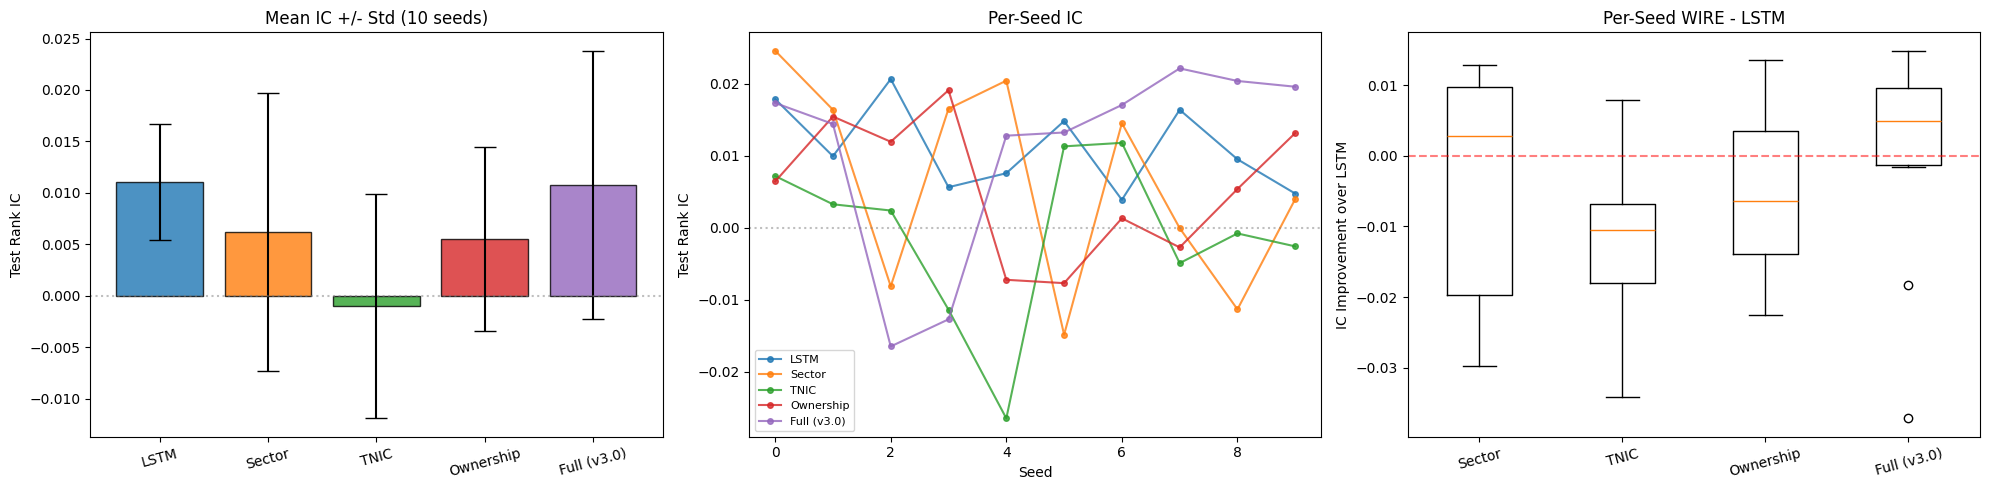

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Mean IC bar chart
names = [name for name, _, _ in CONFIGS]
means = [np.mean(all_results[n]) for n in names]
stds = [np.std(all_results[n]) for n in names]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
axes[0].bar(names, means, yerr=stds, capsize=8, color=colors, alpha=0.8, edgecolor="black")
axes[0].axhline(0, color="gray", ls=":", alpha=0.5)
axes[0].set_ylabel("Test Rank IC")
axes[0].set_title(f"Mean IC +/- Std ({N_SEEDS} seeds)")
axes[0].tick_params(axis='x', rotation=15)

# Per-seed lines
x = np.arange(N_SEEDS)
for name, color in zip(names, colors):
    axes[1].plot(x, all_results[name], 'o-', label=name, color=color, alpha=0.8, markersize=4)
axes[1].axhline(0, color="gray", ls=":", alpha=0.5)
axes[1].set_xlabel("Seed")
axes[1].set_ylabel("Test Rank IC")
axes[1].set_title("Per-Seed IC")
axes[1].legend(fontsize=8)

# Improvement over LSTM (box plot)
deltas = {}
for name in names[1:]:
    deltas[name] = [w - l for w, l in zip(all_results[name], lstm_ics)]
axes[2].boxplot(deltas.values(), labels=deltas.keys())
axes[2].axhline(0, color="red", ls="--", alpha=0.5)
axes[2].set_ylabel("IC Improvement over LSTM")
axes[2].set_title("Per-Seed WIRE - LSTM")
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/ablation_results.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
results_json = {
    "version": "ablation_v3.0",
    "n_seeds": N_SEEDS,
    "n_stocks": N_STOCKS,
    "configs": {
        name: {
            "m_spectral": m,
            "ic_mean": float(np.mean(all_results[name])),
            "ic_std": float(np.std(all_results[name])),
            "per_seed": [float(x) for x in all_results[name]],
        }
        for name, _, m in CONFIGS
    },
    "t_tests_vs_lstm": {
        name: {
            "t_stat": float(ttest_rel(all_results[name], lstm_ics)[0]),
            "p_val": float(ttest_rel(all_results[name], lstm_ics)[1]),
            "delta": float(np.mean(all_results[name]) - np.mean(lstm_ics)),
        }
        for name, _, _ in CONFIGS[1:]
    },
    "graphs": {
        "sector": {"edges": int((A_sector > 0).sum() / 2)},
        "tnic": {"edges": int((A_tnic > 0).sum() / 2)},
        "ownership": {"edges": int((A_ownership > 0).sum() / 2)},
    },
}

with open(f"{OUT_DIR}/ablation_metrics.json", "w") as f:
    json.dump(results_json, f, indent=2)
print(f"Saved to {OUT_DIR}/ablation_metrics.json")

Saved to /content/drive/MyDrive/2026 Spring/STAT 3106/3106_Projects/Projects/output/v_ablation/ablation_metrics.json
